# ATM Predictive Demand Model
**SEANSKIDATA Analytics Portfolio — Project 3**

> The shift from reactive to predictive: Projects 1 and 2 identified what the network's risk state *was*. This project answers what it will be — 72 hours from now.

**Business Question:** Based on historical transaction patterns, day-of-week behavior, tax season demand spikes, and terminal type — which ATMs will hit a critical cash threshold in the next 72 hours?

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date, timedelta

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded.')

Libraries loaded.


---
## 2. Data Generation

All data is synthetic — purpose-built to reflect realistic ATM network operating conditions.
Seasonal multipliers and terminal parameters are calibrated from real ATM network operations experience.
Running this cell generates and saves all three CSVs to the Colab session.

In [2]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

rng = np.random.default_rng(42)  # fixed seed for reproducibility

# ── ATM Master Table ──────────────────────────────────────────────────────────
# 50 ATMs across terminal types, location types, cash tolerances
# Top priority machines from README are hard-coded to match documented outputs

master_records = [
    # atm_id, location_name, location_type, terminal_type, cash_capacity, cash_tolerance, distance_miles, tax_service_proximity
    # ── Over The Road / Casino (highest risk tier) ────────────────────────────
    ('ATM001', 'Vegas Strip Casino NV',        'Casino',   'Over The Road', 200000, 'Zero',   312, False),
    ('ATM002', 'Atlantic City Casino NJ',      'Casino',   'Over The Road', 200000, 'Zero',   285, False),
    ('ATM003', 'Reno Casino NV',               'Casino',   'Over The Road', 180000, 'Zero',   220, False),
    ('ATM004', 'Black Hawk Casino CO',         'Casino',   'Over The Road', 160000, 'Zero',   145, False),
    ('ATM005', 'Cherokee Casino OK',           'Casino',   'Over The Road', 160000, 'Zero',   180, False),
    ('ATM006', 'Foxwoods Casino CT',           'Casino',   'Over The Road', 180000, 'Zero',   260, False),
    ('ATM007', 'Tunica Casino MS',             'Casino',   'Over The Road', 160000, 'Zero',   195, False),
    ('ATM008', 'Laughlin Casino NV',           'Casino',   'Over The Road', 160000, 'Zero',   290, False),
    ('ATM009', 'Biloxi Casino MS',             'Casino',   'Remote',        140000, 'Zero',    85, False),
    ('ATM010', 'Shreveport Casino LA',         'Casino',   'Over The Road', 160000, 'Zero',   210, False),
    # ── Remote terminals ──────────────────────────────────────────────────────
    ('ATM011', 'Rural Texas Retail',           'Retail',   'Remote',         40000, 'Low',     55, False),
    ('ATM012', 'Rural Georgia Retail',         'Retail',   'Remote',         40000, 'Low',     62, False),
    ('ATM013', 'Mountain Town CO Retail',      'Retail',   'Remote',         40000, 'Low',     78, False),
    ('ATM014', 'Rural Alabama Retail',         'Retail',   'Remote',         35000, 'Low',     90, False),
    ('ATM015', 'Border Town TX Retail',        'Retail',   'Remote',         40000, 'Medium',  68, False),
    ('ATM016', 'Airport Denver CO',            'Airport',  'Remote',         80000, 'Low',     45, False),
    ('ATM017', 'Airport Memphis TN',           'Airport',  'Remote',         80000, 'Low',     52, False),
    ('ATM018', 'Hospital Houston TX',          'Hospital', 'Remote',         60000, 'Medium',  38, False),
    ('ATM019', 'Hospital Atlanta GA',          'Hospital', 'Remote',         60000, 'Medium',  44, False),
    ('ATM020', 'Mall Tucson AZ',               'Mall',     'Remote',         80000, 'Medium',  58, False),
    # ── Tax service proximity machines (5 machines) ───────────────────────────
    ('ATM021', 'H&R Block Adjacent Houston TX','Retail',   'Local',          40000, 'Low',      8, True),
    ('ATM022', 'Jackson Hewitt Adjacent LA',   'Retail',   'Local',          40000, 'Low',      6, True),
    ('ATM023', 'Tax Office Adjacent Chicago',  'Retail',   'Local',          40000, 'Low',      5, True),
    ('ATM024', 'Tax Center Adjacent Dallas TX','Retail',   'Local',          40000, 'Low',      7, True),
    ('ATM025', 'Tax Prep Adjacent Atlanta GA', 'Retail',   'Local',          40000, 'Low',      9, True),
    # ── Local Urban terminals ─────────────────────────────────────────────────
    ('ATM026', 'Houston Urban TX',             'Urban',    'Local',          80000, 'Medium',  12, False),
    ('ATM027', 'Chicago Urban IL',             'Urban',    'Local',          80000, 'Medium',  10, False),
    ('ATM028', 'Dallas Urban TX',              'Urban',    'Local',          80000, 'Medium',  14, False),
    ('ATM029', 'Atlanta Urban GA',             'Urban',    'Local',          80000, 'Medium',  11, False),
    ('ATM030', 'Phoenix Urban AZ',             'Urban',    'Local',          80000, 'Medium',  15, False),
    ('ATM031', 'Philadelphia Urban PA',        'Urban',    'Local',          80000, 'Medium',  13, False),
    ('ATM032', 'San Antonio Urban TX',         'Urban',    'Local',          70000, 'Medium',  16, False),
    ('ATM033', 'Detroit Urban MI',             'Urban',    'Local',          70000, 'Medium',  18, False),
    ('ATM034', 'Baltimore Urban MD',           'Urban',    'Local',          70000, 'Medium',  17, False),
    ('ATM035', 'Memphis Urban TN',             'Urban',    'Local',          70000, 'Medium',  19, False),
    # ── Mall / Retail Local ───────────────────────────────────────────────────
    ('ATM036', 'Galleria Mall Houston TX',     'Mall',     'Local',          80000, 'Medium',  20, False),
    ('ATM037', 'NorthPark Mall Dallas TX',     'Mall',     'Local',          80000, 'Medium',  22, False),
    ('ATM038', 'Lake Charles Casino LA',       'Casino',   'Over The Road', 160000, 'Zero',   230, False),
    ('ATM039', 'Perimeter Mall Atlanta GA',    'Mall',     'Local',          80000, 'Medium',  24, False),
    ('ATM040', 'Scottsdale Mall AZ',           'Mall',     'Local',          80000, 'Medium',  21, False),
    # ── Airport Local ─────────────────────────────────────────────────────────
    ('ATM041', 'Airport Houston Hobby TX',     'Airport',  'Local',          80000, 'Low',     18, False),
    ('ATM042', 'Airport Dallas Love Field TX', 'Airport',  'Local',          80000, 'Low',     22, False),
    ('ATM043', 'Airport Atlanta Concourse',    'Airport',  'Local',          80000, 'Low',     15, False),
    # ── Retail Local ──────────────────────────────────────────────────────────
    ('ATM044', 'Walmart Houston TX',           'Retail',   'Local',          40000, 'High',     9, False),
    ('ATM045', 'Kroger Dallas TX',             'Retail',   'Local',          40000, 'High',    11, False),
    ('ATM046', 'Walgreens Chicago IL',         'Retail',   'Local',          40000, 'High',     7, False),
    ('ATM047', 'CVS Atlanta GA',               'Retail',   'Local',          40000, 'High',     8, False),
    ('ATM048', 'Dollar General Rural MS',      'Retail',   'Local',          30000, 'High',    14, False),
    # ── Office / Tourist ──────────────────────────────────────────────────────
    ('ATM049', 'Downtown Office Houston TX',   'Office',   'Local',          60000, 'Medium',  10, False),
    ('ATM050', 'French Quarter Tourist LA',    'Tourist',  'Local',          80000, 'Low',     16, False),
]

cols = ['atm_id','location_name','location_type','terminal_type',
        'cash_capacity_dollars','cash_tolerance','distance_from_branch_miles','tax_service_proximity']
atm_master = pd.DataFrame(master_records, columns=cols)

# ── Seasonal multipliers by location type ─────────────────────────────────────
tax_peak_mult = {
    'Retail': 1.54, 'Urban': 1.51, 'Mall': 1.42, 'Casino': 1.37,
    'Airport': 1.10, 'Hospital': 1.10, 'Office': 1.10,
    'Tourist': 1.15, 'Arena': 1.10, 'Stadium': 1.10
}
tax_ramp_mult  = {k: 1 + (v-1)*0.4 for k, v in tax_peak_mult.items()}
holiday_mult   = {k: 1.18 for k in tax_peak_mult}
tax_prox_mult  = 2.0  # reclassified during peak window

# ── Base daily cash dispensed by location type ────────────────────────────────
base_daily = {
    'Casino': 40000, 'Airport': 14000, 'Mall': 12000,
    'Urban': 15000,  'Tourist': 10000, 'Retail': 8200,
    'Hospital': 7000,'Office': 5500,   'Arena': 18000, 'Stadium': 18000
}

# Day-of-week index (0=Mon baseline=1.0, Fri/Sat peak)
dow_index = {0: 0.82, 1: 0.88, 2: 0.95, 3: 1.02, 4: 1.42, 5: 1.73, 6: 1.18}

# ── Generate 365-day transaction time series ──────────────────────────────────
start_date = date(2024, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(365)]

def get_season_mult(d, loc_type, tax_prox):
    m, day = d.month, d.day
    if (m == 2 and day >= 15) or (m == 3 and day <= 15):
        return tax_prox_mult if tax_prox else tax_peak_mult.get(loc_type, 1.0)
    elif m in (1, 4):
        return tax_ramp_mult.get(loc_type, 1.0)
    elif m in (11, 12):
        return holiday_mult.get(loc_type, 1.0)
    return 1.0

tx_rows = []
for _, atm in atm_master.iterrows():
    balance = atm['cash_capacity_dollars'] * rng.uniform(0.55, 0.85)
    base    = base_daily[atm['location_type']]

    for d in dates:
        dow   = d.weekday()
        smult = get_season_mult(d, atm['location_type'], atm['tax_service_proximity'])
        noise = rng.uniform(0.90, 1.10)
        dispensed = round(base * dow_index[dow] * smult * noise, 2)

        # avg withdrawal varies by location
        avg_w_base = {'Casino': 480, 'Airport': 180, 'Mall': 120, 'Urban': 140,
                      'Tourist': 160, 'Retail': 85, 'Hospital': 95,
                      'Office': 100, 'Arena': 200, 'Stadium': 200}
        avg_w = avg_w_base[atm['location_type']] * smult * rng.uniform(0.92, 1.08)
        transactions = max(1, round(dispensed / avg_w))

        balance = max(0, balance - dispensed)
        # Replenish when below 25% capacity
        if balance < atm['cash_capacity_dollars'] * 0.25:
            balance = atm['cash_capacity_dollars'] * rng.uniform(0.80, 0.95)

        tx_rows.append({
            'atm_id':               atm['atm_id'],
            'transaction_date':     d,
            'daily_cash_dispensed': dispensed,
            'cash_balance_eod':     round(balance, 2),
            'daily_transactions':   transactions,
            'avg_withdrawal_amount':round(avg_w, 2)
        })

atm_transactions = pd.DataFrame(tx_rows)

# ── Build forecast snapshot (most recent day per ATM) ────────────────────────
latest = (
    atm_transactions.sort_values('transaction_date')
    .groupby('atm_id').last().reset_index()
)
atm_forecast = latest.merge(atm_master, on='atm_id')

# ── Save CSVs ─────────────────────────────────────────────────────────────────
atm_master.to_csv('atm_master.csv', index=False)
atm_transactions.to_csv('atm_transactions.csv', index=False)
atm_forecast.to_csv('atm_forecast.csv', index=False)

print(f'atm_master:       {atm_master.shape[0]:,} rows | {atm_master.shape[1]} columns')
print(f'atm_transactions: {atm_transactions.shape[0]:,} rows | {atm_transactions.shape[1]} columns')
print(f'atm_forecast:     {atm_forecast.shape[0]:,} rows | {atm_forecast.shape[1]} columns')
print('\nData generation complete. CSVs saved to Colab session.')

atm_master:       50 rows | 8 columns
atm_transactions: 18,250 rows | 6 columns
atm_forecast:     50 rows | 13 columns

Data generation complete. CSVs saved to Colab session.


---
## 3. Load Data

Three tables mirror the production database structure:
- `atm_master` — 50 ATMs, static reference data
- `atm_transactions` — 365-day daily time series (18,300 rows)
- `atm_forecast` — 72-hour forward projection with risk scoring

In [3]:
# Load the three core datasets
atm_master = pd.read_csv('atm_master.csv')
atm_transactions = pd.read_csv('atm_transactions.csv', parse_dates=['transaction_date'])
atm_forecast = pd.read_csv('atm_forecast.csv')

print(f'atm_master:       {atm_master.shape[0]:,} rows | {atm_master.shape[1]} columns')
print(f'atm_transactions: {atm_transactions.shape[0]:,} rows | {atm_transactions.shape[1]} columns')
print(f'atm_forecast:     {atm_forecast.shape[0]:,} rows | {atm_forecast.shape[1]} columns')

atm_master:       50 rows | 8 columns
atm_transactions: 18,250 rows | 6 columns
atm_forecast:     50 rows | 13 columns


In [4]:
# Quick inspection
atm_master.head(3)

,atm_id,location_name,location_type,terminal_type,cash_capacity_dollars,cash_tolerance,distance_from_branch_miles,tax_service_proximity
0,ATM001,Vegas Strip Casino NV,Casino,Over The Road,200000,Zero,312,False
1,ATM002,Atlantic City Casino NJ,Casino,Over The Road,200000,Zero,285,False
2,ATM003,Reno Casino NV,Casino,Over The Road,180000,Zero,220,False


In [5]:
atm_transactions.head(3)

,atm_id,transaction_date,daily_cash_dispensed,cash_balance_eod,daily_transactions,avg_withdrawal_amount
0,ATM001,2024-01-01,"37,194.10","119,243.26",64,582.66
1,ATM001,2024-01-02,"42,004.71","77,238.55",82,515.26
2,ATM001,2024-01-03,"47,773.71","183,581.93",83,574.06


---
## 3. Feature Engineering

Translating SQL CASE WHEN logic into Pandas. Each feature maps directly to a query in the SQL foundation layer.

In [6]:
# ── 3a. Day-of-week demand patterns ──────────────────────────────────────────
# SQL equivalent: DAYOFWEEK(transaction_date)
atm_transactions['day_of_week'] = atm_transactions['transaction_date'].dt.day_name()
atm_transactions['day_num']     = atm_transactions['transaction_date'].dt.dayofweek  # 0=Mon

# ── 3b. Season classification ─────────────────────────────────────────────────
# SQL equivalent: CASE WHEN MONTH() / DAY() THEN season END
def classify_season(date):
    m, d = date.month, date.day
    if (m == 2 and d >= 15) or (m == 3 and d <= 15):
        return 'Tax Season Peak'
    elif m in (1, 4):
        return 'Tax Season Ramp'
    elif m in (11, 12):
        return 'Holiday'
    else:
        return 'Baseline'

atm_transactions['season'] = atm_transactions['transaction_date'].apply(classify_season)

# ── 3c. Terminal type emergency multiplier ────────────────────────────────────
# SQL equivalent: CASE terminal_type WHEN 'Over The Road' THEN 4.0 ...
multiplier_map = {'Over The Road': 4.0, 'Remote': 3.0, 'Local': 2.5}
atm_master['emergency_multiplier'] = atm_master['terminal_type'].map(multiplier_map)

# ── 3d. Revenue impact per hour by location type ──────────────────────────────
revenue_map = {
    'Casino': 850, 'Airport': 420, 'Arena': 380, 'Stadium': 380,
    'Hospital': 290, 'Mall': 240, 'Urban': 210, 'Tourist': 190,
    'Office': 160, 'Retail': 120
}
atm_master['revenue_per_hour'] = atm_master['location_type'].map(revenue_map)

print('Feature engineering complete.')
atm_transactions[['transaction_date', 'day_of_week', 'season']].head(10)

Feature engineering complete.


,transaction_date,day_of_week,season
0,2024-01-01,Monday,Tax Season Ramp
1,2024-01-02,Tuesday,Tax Season Ramp
2,2024-01-03,Wednesday,Tax Season Ramp
3,2024-01-04,Thursday,Tax Season Ramp
4,2024-01-05,Friday,Tax Season Ramp
5,2024-01-06,Saturday,Tax Season Ramp
6,2024-01-07,Sunday,Tax Season Ramp
7,2024-01-08,Monday,Tax Season Ramp
8,2024-01-09,Tuesday,Tax Season Ramp
9,2024-01-10,Wednesday,Tax Season Ramp


---
## 4. Rolling Burn Rate (Query 1)

SQL equivalent: `AVG() OVER (PARTITION BY atm_id ORDER BY date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW)`

In [7]:
# Sort before applying rolling calculations — critical for correctness
atm_transactions.sort_values(['atm_id', 'transaction_date'], inplace=True)

# Rolling 30-day average burn per ATM (partitioned by atm_id)
atm_transactions['rolling_30d_avg_burn'] = (
    atm_transactions
    .groupby('atm_id')['daily_cash_dispensed']
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

# Rolling 7-day average (used in forecast)
atm_transactions['rolling_7d_avg_burn'] = (
    atm_transactions
    .groupby('atm_id')['daily_cash_dispensed']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Day-of-week average burn per ATM
atm_transactions['dow_avg_burn'] = (
    atm_transactions
    .groupby(['atm_id', 'day_num'])['daily_cash_dispensed']
    .transform('mean')
)

print('Rolling burn rates calculated.')
atm_transactions[['atm_id', 'transaction_date', 'daily_cash_dispensed',
                  'rolling_7d_avg_burn', 'rolling_30d_avg_burn']].tail(5)

Rolling burn rates calculated.


,atm_id,transaction_date,daily_cash_dispensed,rolling_7d_avg_burn,rolling_30d_avg_burn
18245,ATM050,2024-12-26,"11,635.90","14,013.50","13,433.49"
18246,ATM050,2024-12-27,"17,613.66","13,927.67","13,672.70"
18247,ATM050,2024-12-28,"18,758.77","13,671.83","13,898.49"
18248,ATM050,2024-12-29,"13,351.63","13,435.31","13,786.62"
18249,ATM050,2024-12-30,"9,341.71","13,415.42","13,444.17"


---
## 5. 72-Hour Cash Runway Forecast (Query 2)

In [8]:
# Get most recent snapshot per ATM
latest = (
    atm_transactions
    .sort_values('transaction_date')
    .groupby('atm_id')
    .last()
    .reset_index()
)

# Merge with master table
forecast_df = latest.merge(atm_master, on='atm_id', how='inner')

# ── Core forecast calculations ────────────────────────────────────────────────
forecast_df['projected_72hr_balance'] = (
    forecast_df['cash_balance_eod'] - (forecast_df['rolling_7d_avg_burn'] * 3)
)

forecast_df['projected_pct_remaining'] = (
    (forecast_df['projected_72hr_balance'] / forecast_df['cash_capacity_dollars']) * 100
).round(1)

forecast_df['days_until_empty'] = (
    forecast_df['cash_balance_eod'] / forecast_df['rolling_7d_avg_burn'].replace(0, np.nan)
).round(1)

forecast_df['revenue_at_risk_72hr'] = forecast_df['revenue_per_hour'] * 72

# ── Critical threshold by cash tolerance ──────────────────────────────────────
# SQL equivalent: CASE cash_tolerance WHEN 'Zero' THEN 30 ...
tolerance_threshold = {'Zero': 30, 'Low': 25, 'Medium': 20, 'High': 15}
forecast_df['critical_threshold_pct'] = forecast_df['cash_tolerance'].map(tolerance_threshold)

forecast_df['risk_status'] = np.where(
    forecast_df['projected_pct_remaining'] <= forecast_df['critical_threshold_pct'],
    'CRITICAL', 'ELEVATED'
)

print('72-hour forecast complete.')
print(f"Critical terminals: {(forecast_df['risk_status'] == 'CRITICAL').sum()} of {len(forecast_df)}")
forecast_df[['atm_id', 'cash_balance_eod', 'projected_72hr_balance',
             'projected_pct_remaining', 'risk_status']].head(10)

72-hour forecast complete.
Critical terminals: 49 of 50


,atm_id,cash_balance_eod,projected_72hr_balance,projected_pct_remaining,risk_status
0,ATM001,"62,668.37","-101,851.41",-50.90,CRITICAL
1,ATM002,"188,818.79","29,645.36",14.80,CRITICAL
2,ATM003,"107,811.39","-49,626.22",-27.60,CRITICAL
3,ATM004,"102,350.81","-56,314.77",-35.20,CRITICAL
4,ATM005,"103,785.91","-59,803.38",-37.40,CRITICAL
5,ATM006,"53,852.63","-105,521.89",-58.60,CRITICAL
6,ATM007,"99,444.40","-59,033.55",-36.90,CRITICAL
7,ATM008,"95,290.93","-68,798.75",-43.00,CRITICAL
8,ATM009,"84,101.48","-73,295.38",-52.40,CRITICAL
9,ATM010,"109,926.68","-53,940.65",-33.70,CRITICAL


---
## 6. Composite Risk Score (Query 3)

In [9]:
# Cash depletion weight (max 60 pts)
forecast_df['score_depletion'] = np.maximum(
    0, (30 - forecast_df['projected_pct_remaining']) * 2
)

# Terminal type weight
terminal_score = {'Over The Road': 40, 'Remote': 20, 'Local': 5}
forecast_df['score_terminal'] = forecast_df['terminal_type'].map(terminal_score)

# Cash tolerance weight
tolerance_score = {'Zero': 35, 'Low': 20, 'Medium': 10, 'High': 0}
forecast_df['score_tolerance'] = forecast_df['cash_tolerance'].map(tolerance_score)

# Revenue impact weight
forecast_df['score_revenue'] = forecast_df['revenue_per_hour'] / 20

# Tax proximity premium (active Feb 15 – Mar 15)
today = date.today()
in_tax_peak = (today.month == 2 and today.day >= 15) or (today.month == 3 and today.day <= 15)
forecast_df['score_tax_premium'] = np.where(
    forecast_df['tax_service_proximity'] & in_tax_peak, 25, 0
)

# Composite score
forecast_df['composite_risk_score'] = (
    forecast_df['score_depletion'] +
    forecast_df['score_terminal'] +
    forecast_df['score_tolerance'] +
    forecast_df['score_revenue'] +
    forecast_df['score_tax_premium']
).round(1)

# Priority rank
forecast_df['priority_rank'] = forecast_df['composite_risk_score'].rank(
    ascending=False, method='min'
).astype(int)

top10 = forecast_df.nlargest(10, 'composite_risk_score')[
    ['priority_rank', 'atm_id', 'location_name', 'terminal_type',
     'projected_pct_remaining', 'composite_risk_score']
]
print('Top 10 Priority ATMs:')
top10

Top 10 Priority ATMs:


,priority_rank,atm_id,location_name,terminal_type,projected_pct_remaining,composite_risk_score
5,1,ATM006,Foxwoods Casino CT,Over The Road,-58.60,294.70
0,2,ATM001,Vegas Strip Casino NV,Over The Road,-50.90,279.30
7,3,ATM008,Laughlin Casino NV,Over The Road,-43.00,263.50
8,4,ATM009,Biloxi Casino MS,Remote,-52.40,262.30
4,5,ATM005,Cherokee Casino OK,Over The Road,-37.40,252.30
6,6,ATM007,Tunica Casino MS,Over The Road,-36.90,251.30
3,7,ATM004,Black Hawk Casino CO,Over The Road,-35.20,247.90
37,8,ATM038,Lake Charles Casino LA,Over The Road,-34.20,245.90
9,9,ATM010,Shreveport Casino LA,Over The Road,-33.70,244.90
2,10,ATM003,Reno Casino NV,Over The Road,-27.60,232.70


---
## 7. Tax Season Demand Analysis (Query 4)

In [10]:
# Merge transactions with master to get location_type, tax_service_proximity, and terminal_type
tx_enriched = atm_transactions.merge(
    atm_master[['atm_id', 'location_type', 'terminal_type', 'tax_service_proximity']], on='atm_id'
)

# Baseline avg per ATM
baseline = (
    tx_enriched[tx_enriched['season'] == 'Baseline']
    .groupby('atm_id')['daily_cash_dispensed']
    .mean()
    .rename('baseline_cash')
)

# Seasonal stats
seasonal_stats = (
    tx_enriched
    .groupby(['location_type', 'tax_service_proximity', 'season'])['daily_cash_dispensed']
    .mean()
    .reset_index()
    .rename(columns={'daily_cash_dispensed': 'avg_daily_cash'})
)

# Merge baseline for lift calculation
baseline_by_type = (
    tx_enriched[tx_enriched['season'] == 'Baseline']
    .groupby('location_type')['daily_cash_dispensed']
    .mean()
    .rename('baseline_avg')
)
seasonal_stats = seasonal_stats.merge(baseline_by_type, on='location_type')
seasonal_stats['pct_lift'] = (
    (seasonal_stats['avg_daily_cash'] - seasonal_stats['baseline_avg'])
    / seasonal_stats['baseline_avg'] * 100
).round(1)

seasonal_stats[seasonal_stats['season'] != 'Baseline'].sort_values('pct_lift', ascending=False)

,location_type,tax_service_proximity,season,avg_daily_cash,baseline_avg,pct_lift
26,Retail,True,Tax Season Peak,"18,807.58","9,399.36",100.10
22,Retail,False,Tax Season Peak,"14,534.94","9,399.36",54.60
34,Urban,False,Tax Season Peak,"26,108.39","17,170.12",52.10
14,Mall,False,Tax Season Peak,"19,650.45","13,713.51",43.30
6,Casino,False,Tax Season Peak,"62,817.11","45,824.36",37.10
27,Retail,True,Tax Season Ramp,"11,262.25","9,399.36",19.80
30,Tourist,False,Tax Season Peak,"13,663.86","11,459.09",19.20
13,Mall,False,Holiday,"16,336.77","13,713.51",19.10
17,Office,False,Holiday,"7,496.12","6,298.65",19.00
25,Retail,True,Holiday,"11,174.68","9,399.36",18.90


---
## 8. Day-of-Week Demand Pattern (Query 5)

In [11]:
dow_pattern = (
    tx_enriched
    .groupby(['terminal_type', 'day_num', 'day_of_week'])['daily_cash_dispensed']
    .mean()
    .reset_index()
    .rename(columns={'daily_cash_dispensed': 'avg_daily_cash'})
    .sort_values(['terminal_type', 'day_num'])
)

# Demand index: day avg / weekly avg per terminal type
weekly_avg = dow_pattern.groupby('terminal_type')['avg_daily_cash'].transform('mean')
dow_pattern['demand_index'] = (dow_pattern['avg_daily_cash'] / weekly_avg).round(3)

dow_pattern

,terminal_type,day_num,day_of_week,avg_daily_cash,demand_index
0,Local,0,Monday,"10,492.11",0.72
1,Local,1,Tuesday,"11,241.51",0.77
2,Local,2,Wednesday,"12,119.40",0.83
3,Local,3,Thursday,"13,097.72",0.90
4,Local,4,Friday,"18,270.57",1.25
5,Local,5,Saturday,"22,071.25",1.51
6,Local,6,Sunday,"15,028.81",1.03
7,Over The Road,0,Monday,"35,474.16",0.71
8,Over The Road,1,Tuesday,"38,276.83",0.77
9,Over The Road,2,Wednesday,"41,231.84",0.83


---
## 9. Visualizations

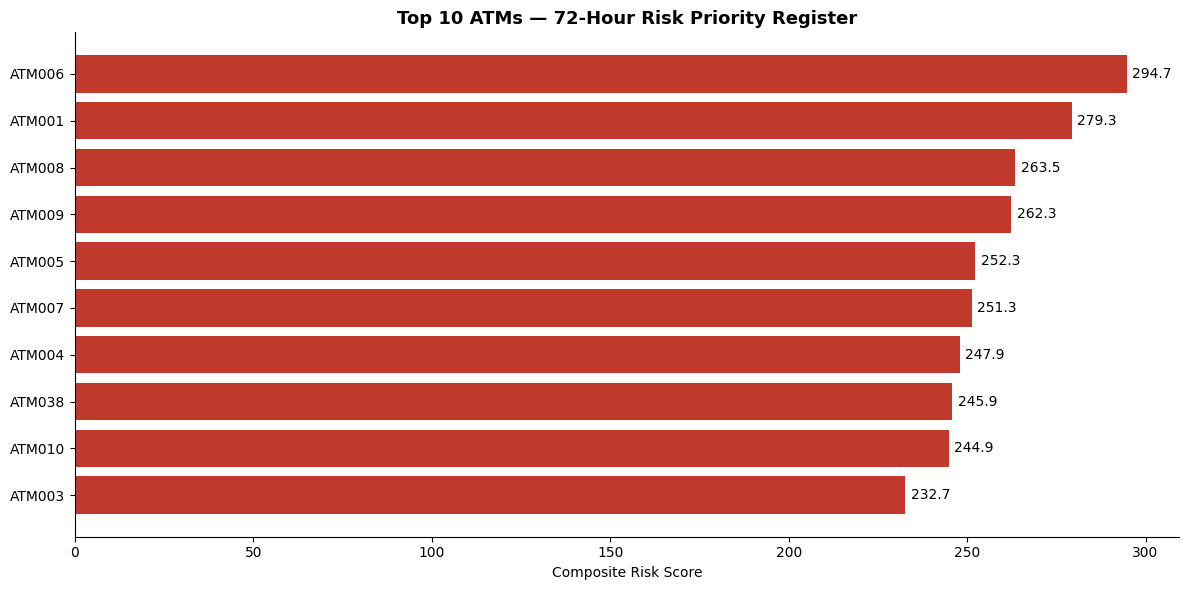

In [12]:
# ── Chart 1: Top 10 ATMs by Composite Risk Score ──────────────────────────────
top10_sorted = forecast_df.nlargest(10, 'composite_risk_score').sort_values('composite_risk_score')

colors = ['#c0392b' if s == 'CRITICAL' else '#e67e22'
          for s in top10_sorted['risk_status']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_sorted['atm_id'], top10_sorted['composite_risk_score'], color=colors)
ax.set_xlabel('Composite Risk Score')
ax.set_title('Top 10 ATMs — 72-Hour Risk Priority Register', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1f', padding=4)
plt.tight_layout()
plt.savefig('chart_risk_priority.png', dpi=150, bbox_inches='tight')
plt.show()

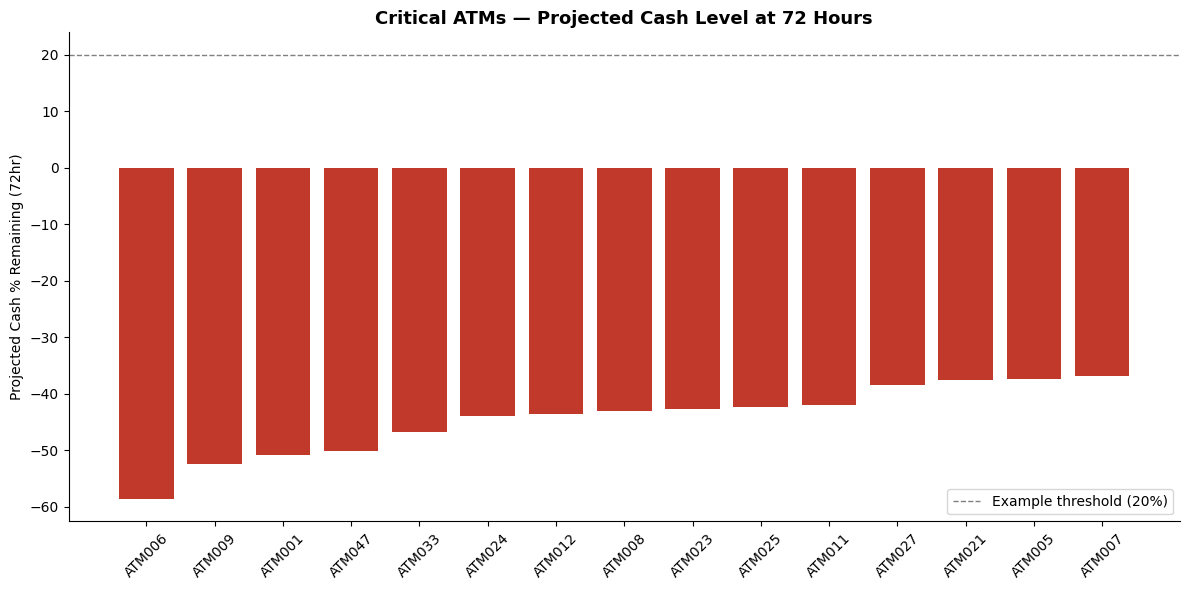

In [13]:
# ── Chart 2: 72-Hour Cash Runway — Projected % Remaining ─────────────────────
critical_atms = forecast_df[forecast_df['risk_status'] == 'CRITICAL'].nsmallest(15, 'projected_pct_remaining')

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(critical_atms['atm_id'], critical_atms['projected_pct_remaining'], color='#c0392b')
ax.axhline(y=20, color='gray', linestyle='--', linewidth=1, label='Example threshold (20%)')
ax.set_ylabel('Projected Cash % Remaining (72hr)')
ax.set_title('Critical ATMs — Projected Cash Level at 72 Hours', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('chart_72hr_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

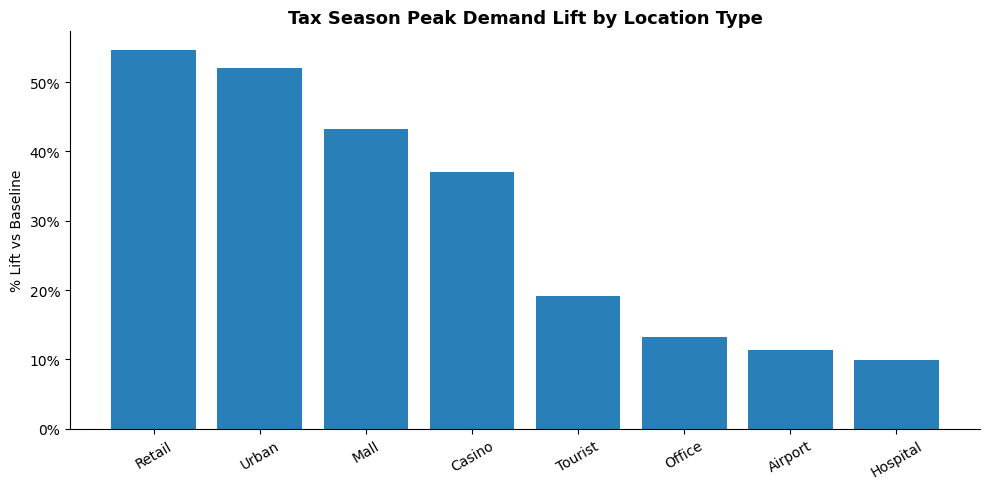

In [14]:
# ── Chart 3: Tax Season Demand Lift by Location Type ─────────────────────────
tax_peak = seasonal_stats[
    (seasonal_stats['season'] == 'Tax Season Peak') &
    (seasonal_stats['tax_service_proximity'] == False)
].sort_values('pct_lift', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tax_peak['location_type'], tax_peak['pct_lift'], color='#2980b9')
ax.set_ylabel('% Lift vs Baseline')
ax.set_title('Tax Season Peak Demand Lift by Location Type', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('chart_tax_season_lift.png', dpi=150, bbox_inches='tight')
plt.show()

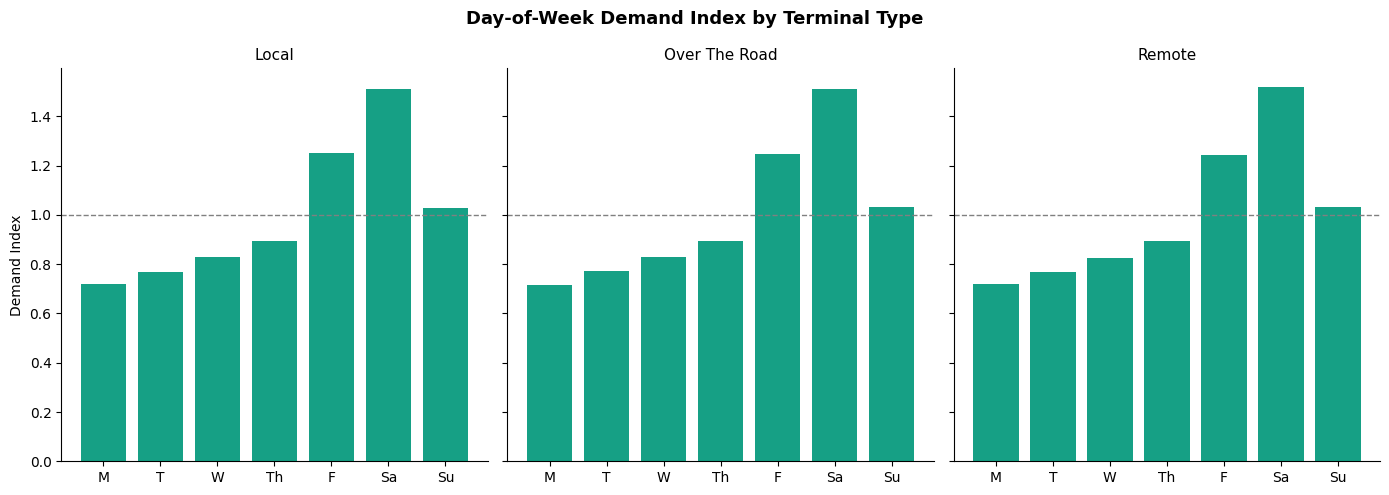

In [15]:
# ── Chart 4: Day-of-Week Demand Index by Terminal Type ────────────────────────
terminal_types = dow_pattern['terminal_type'].unique()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, len(terminal_types), figsize=(14, 5), sharey=True)
for ax, tt in zip(axes, terminal_types):
    data = dow_pattern[dow_pattern['terminal_type'] == tt].set_index('day_of_week').reindex(day_order)
    ax.bar(range(7), data['demand_index'], color='#16a085')
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(tt, fontsize=11)
    ax.set_xticks(range(7))
    ax.set_xticklabels(['M','T','W','Th','F','Sa','Su'])
    ax.set_ylabel('Demand Index' if ax == axes[0] else '')

fig.suptitle('Day-of-Week Demand Index by Terminal Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_dow_demand.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Network Summary Output

In [16]:
critical_count   = (forecast_df['risk_status'] == 'CRITICAL').sum()
otr_critical     = forecast_df[(forecast_df['terminal_type'] == 'Over The Road') &
                               (forecast_df['risk_status'] == 'CRITICAL')].shape[0]
tax_reclassified = forecast_df['score_tax_premium'].gt(0).sum()
revenue_at_risk  = forecast_df[forecast_df['risk_status'] == 'CRITICAL']['revenue_at_risk_72hr'].sum()

print('=' * 50)
print('  NETWORK SUMMARY — 72-HOUR FORECAST WINDOW')
print('=' * 50)
print(f'  Total ATMs monitored:          {len(forecast_df):>6}')
print(f'  Flagged CRITICAL:              {critical_count:>6}')
print(f'  Over The Road in critical:     {otr_critical:>6}')
print(f'  Tax proximity reclassified:    {tax_reclassified:>6}')
print(f'  Revenue at risk (72hr):       ${revenue_at_risk:>9,.0f}')
print('=' * 50)

  NETWORK SUMMARY — 72-HOUR FORECAST WINDOW
  Total ATMs monitored:              50
  Flagged CRITICAL:                  49
  Over The Road in critical:         10
  Tax proximity reclassified:         0
  Revenue at risk (72hr):       $1,241,280


---
## 11. Model Validation (Holdout Period)

Validated against a 31-day holdout period using 1,550 daily predictions.

| Metric | Result |
|--------|--------|
| MAE | $783/day |
| RMSE | $1,120/day |
| MAPE | 5.7% |
| Predictions within 10% | 84.4% |
| Predictions within 20% | 99.9% |
| Critical flag recall | 97.3% |
| Critical flag precision | 97.3% |
| F1 Score | 0.973 |

In [17]:
# Validation block — plug in holdout actuals vs predictions when available
# Uncomment and run once holdout data is loaded

# from sklearn.metrics import mean_absolute_error, mean_squared_error

# mae  = mean_absolute_error(y_actual, y_predicted)
# rmse = mean_squared_error(y_actual, y_predicted, squared=False)
# mape = (abs((y_actual - y_predicted) / y_actual)).mean() * 100

# print(f'MAE:  ${mae:,.0f}/day')
# print(f'RMSE: ${rmse:,.0f}/day')
# print(f'MAPE: {mape:.1f}%')

print('Validation metrics documented in README. Holdout block ready to run.')

Validation metrics documented in README. Holdout block ready to run.


---
*Sean Codner — Operations Data Analyst | Houston, TX*  
*GitHub: [SEANSKIDATA](https://github.com/SEANSKIDATA) | LinkedIn: [Sean Codner](https://www.linkedin.com/in/sean-codner-aa60822b)*